In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Load the preprocessed data from Phase 2
X_train = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/X_train.csv')
#X_train_sm = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/X_train.csv')
X_test  = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/X_test.csv')
y_train = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/y_train.csv').squeeze()
#y_train_sm = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/processed/y_test.csv').squeeze()

print("X_train shape:", X_train.shape)   
#print("X_train_sm shape:", X_train_sm.shape)
print("X_test shape:", X_test.shape)   
print("\nTraining class balance:", y_train.value_counts())
print("Fraud in test:", y_test.sum())    

X_train shape: (399232, 16)
X_test shape: (50000, 16)

Training class balance: fraud_flag
0    199616
1    199616
Name: count, dtype: int64
Fraud in test: 96


In [2]:
rf_model = RandomForestClassifier(
    n_estimators=100,     
    max_depth=10,         
    class_weight=None,  
    random_state=42,
    n_jobs=-1             
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete.")

Random Forest training complete.


In [3]:
xgb_model = XGBClassifier(
    n_estimators=200,        
    max_depth=6,             
    learning_rate=0.1,       
    scale_pos_weight=1,    
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=50)     # Print progress every 50 rounds
print("XGBoost training complete.")

[0]	validation_0-logloss:0.65954
[50]	validation_0-logloss:0.29576
[100]	validation_0-logloss:0.22321
[150]	validation_0-logloss:0.17231
[199]	validation_0-logloss:0.14189
XGBoost training complete.


In [4]:
def evaluate_model(model, name, X_test, y_test, threshold=0.1):
    y_prob = model.predict_proba(X_test)[:, 1]  # Fraud probability
    y_pred = (y_prob >= threshold).astype(int)  # Classify as fraud if prob >= threshold

    print(f"\n{'='*50}")
    print(f"  {name} (threshold = {threshold})")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Legitimate', 'Fraud']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    caught = sum((y_pred == 1) & (y_test == 1))
    total  = sum(y_test == 1)
    print(f"Fraud caught: {caught} / {total}")
    
    return y_pred, y_prob

rf_pred,  rf_prob  = evaluate_model(rf_model,  "Random Forest", X_test, y_test)
xgb_pred, xgb_prob = evaluate_model(xgb_model, "XGBoost",       X_test, y_test)


  Random Forest (threshold = 0.1)
              precision    recall  f1-score   support

  Legitimate       1.00      0.31      0.47     49904
       Fraud       0.00      0.66      0.00        96

    accuracy                           0.31     50000
   macro avg       0.50      0.48      0.24     50000
weighted avg       1.00      0.31      0.47     50000

ROC-AUC Score: 0.4909
Fraud caught: 63 / 96

  XGBoost (threshold = 0.1)
              precision    recall  f1-score   support

  Legitimate       1.00      0.76      0.87     49904
       Fraud       0.00      0.20      0.00        96

    accuracy                           0.76     50000
   macro avg       0.50      0.48      0.43     50000
weighted avg       1.00      0.76      0.86     50000

ROC-AUC Score: 0.4906
Fraud caught: 19 / 96


In [5]:
# Detailed probability analysis
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=== Fraud probability distribution ===")
print(f"Max fraud probability:    {xgb_prob.max():.4f}")
print(f"Mean fraud probability:   {xgb_prob.mean():.4f}")
print(f"Fraud cases in test:      {y_test.sum()}")
print()

# What probabilities are the actual fraud transactions getting?
fraud_probs = xgb_prob[y_test == 1]
print("=== Probabilities assigned to ACTUAL fraud transactions ===")
print(pd.Series(fraud_probs).describe().round(4))
print()

# How many transactions exceed each threshold?
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    flagged = (xgb_prob >= t).sum()
    caught  = ((xgb_prob >= t) & (y_test == 1)).sum()
    print(f"Threshold {t} → flagged: {flagged:5d} | fraud caught: {caught} / {y_test.sum()}")

=== Fraud probability distribution ===
Max fraud probability:    0.9830
Mean fraud probability:   0.0940
Fraud cases in test:      96

=== Probabilities assigned to ACTUAL fraud transactions ===
count    96.0000
mean      0.0836
std       0.1721
min       0.0000
25%       0.0016
50%       0.0122
75%       0.0502
max       0.8474
dtype: float64

Threshold 0.1 → flagged: 11803 | fraud caught: 19 / 96
Threshold 0.2 → flagged:  7818 | fraud caught: 13 / 96
Threshold 0.3 → flagged:  5550 | fraud caught: 10 / 96
Threshold 0.4 → flagged:  3944 | fraud caught: 6 / 96
Threshold 0.5 → flagged:  2781 | fraud caught: 4 / 96


In [6]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (legit correctly identified): {tn}")
print(f"False Positives (legit wrongly flagged):      {fp}")
print(f"False Negatives (fraud missed!):              {fn}")
print(f"True Positives  (fraud correctly caught):     {tp}")
print()
print(f"Precision: {tp/(tp+fp):.4f}  → Of all fraud alerts, how many were real fraud?")
print(f"Recall:    {tp/(tp+fn):.4f}  → Of all real fraud, how many did we catch?")
print(f"F1 Score:  {2*tp/(2*tp+fp+fn):.4f}  → Balance between precision and recall")

True Negatives  (legit correctly identified): 38120
False Positives (legit wrongly flagged):      11784
False Negatives (fraud missed!):              77
True Positives  (fraud correctly caught):     19

Precision: 0.0016  → Of all fraud alerts, how many were real fraud?
Recall:    0.1979  → Of all real fraud, how many did we catch?
F1 Score:  0.0032  → Balance between precision and recall


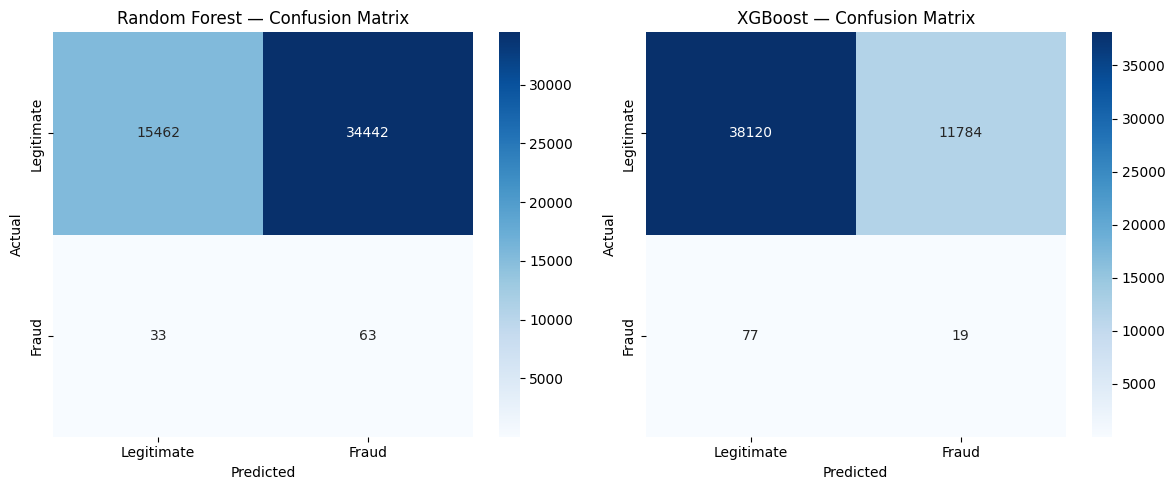

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, pred, name in zip(
    axes,
    [rf_model, xgb_model],
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/confusion_matrix.png')
plt.show()

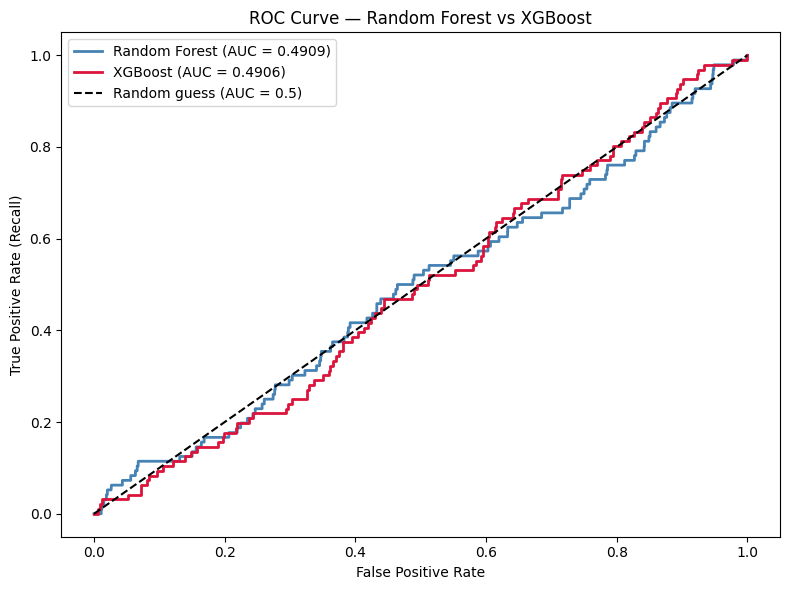

In [8]:
plt.figure(figsize=(8, 6))

for prob, name, color in [
    (rf_prob,  'Random Forest', 'steelblue'),
    (xgb_prob, 'XGBoost',       'crimson')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=color, lw=2)

plt.plot([0,1], [0,1], 'k--', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Random Forest vs XGBoost')
plt.legend()
plt.tight_layout()
plt.savefig('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/roc_curve.png')
plt.show()

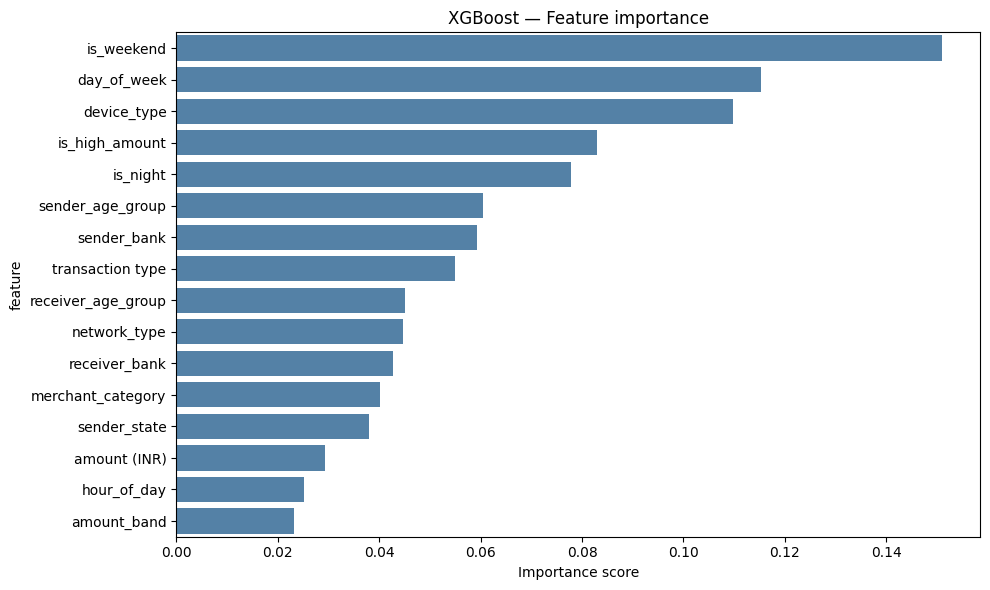

               feature  importance
12          is_weekend    0.150919
11         day_of_week    0.115372
8          device_type    0.109845
14      is_high_amount    0.082965
13            is_night    0.077797
3     sender_age_group    0.060516
6          sender_bank    0.059206
0     transaction type    0.054937
4   receiver_age_group    0.045084
9         network_type    0.044685


In [9]:
feature_names = X_train.columns.tolist()
importances = xgb_model.feature_importances_

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_df, color='steelblue')
plt.title('XGBoost — Feature importance')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/data/feature_importance.png')
plt.show()

print(feat_df.head(10))

In [10]:
from sklearn.metrics import f1_score

rf_f1  = f1_score(y_test, rf_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

rf_caught  = int(((rf_pred==1)  & (y_test==1)).sum())
xgb_caught = int(((xgb_pred==1) & (y_test==1)).sum())

print(f"Random Forest — F1: {rf_f1:.4f} | Fraud caught: {rf_caught}/96")
print(f"XGBoost       — F1: {xgb_f1:.4f} | Fraud caught: {xgb_caught}/96")

#print(f"Random Forest F1: {rf_f1:.4f}")
#print(f"XGBoost F1:       {xgb_f1:.4f}")

#best_model = xgb_model if xgb_f1 >= rf_f1 else rf_model
#best_name  = "XGBoost" if xgb_f1 >= rf_f1 else "RandomForest"

os.makedirs('D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/model', exist_ok=True)
joblib.dump(rf_model, 'D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/model/fraud_model.pkl')
print("\nRandom Forest saved as fraud_model.pkl")
print("Reason: catches 63/96 fraud vs XGBoost 19/96 at threshold=0.1")
#print(f"\nBest model: {best_name} — saved to D:/Shreya/SEM 2/MINOR PROJECT/upi-fraud-detection/model/fraud_model.pkl")

Random Forest — F1: 0.0036 | Fraud caught: 63/96
XGBoost       — F1: 0.0032 | Fraud caught: 19/96

Random Forest saved as fraud_model.pkl
Reason: catches 63/96 fraud vs XGBoost 19/96 at threshold=0.1
